In [10]:
import pandas as pd
import numpy as np

df = pd.read_csv("netflix_titles.csv")
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [12]:
print(df.shape)        # rows, columns
print(df.columns)      # column names
print(df.info())       # data types
print(df.describe())   # statistical summary

(8807, 12)
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB
None
       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925

In [13]:
print(df.isnull().sum())

# Fill missing values
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Not Available")

# Drop rows with missing country
df = df.dropna(subset=['country'])


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [14]:
df = df.drop_duplicates()

In [16]:
type_count = df['type'].value_counts()
print(type_count)

type
Movie      5691
TV Show    2285
Name: count, dtype: int64


In [17]:
top_countries = df['country'].value_counts().head(10)
print(top_countries)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


In [18]:
ratings = df['rating'].value_counts()
print(ratings)

rating
TV-MA       2931
TV-14       1930
R            788
TV-PG        773
PG-13        482
PG           281
TV-Y7        236
TV-Y         227
TV-G         190
NR            80
G             41
TV-Y7-FV       5
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


In [19]:
top_countries = df['country'].value_counts().head(10)
print(top_countries)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


In [20]:
movies = df[df['type'] == 'Movie']

movies['duration'] = movies['duration'].str.replace(' min', '')
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

print(movies['duration'].max())

312.0


In [24]:

recent_movies = df[df['release_year'] > 2015]
print(recent_movies.head())

  show_id     type                          title         director  \
0      s1    Movie           Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show                  Blood & Water          Unknown   
4      s5  TV Show                   Kota Factory          Unknown   
8      s9  TV Show  The Great British Baking Show  Andy Devonshire   
9     s10    Movie                   The Starling   Theodore Melfi   

                                                cast         country  \
0                                      Not Available   United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...    South Africa   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...           India   
8  Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...  United Kingdom   
9  Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...   United States   

  date_added  release_year rating   duration  \
0 2021-09-25          2020  PG-13     90 min   
1 2021-09-24          2021  TV-MA  2 Seasons   
4 

In [23]:

year_count = df.groupby('year_added').size()
print(year_count)

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      70
2016.0     399
2017.0    1099
2018.0    1507
2019.0    1843
2020.0    1770
2021.0    1140
dtype: int64


In [25]:
data = np.array(df['release_year'])

print("Mean:", np.mean(data))
print("Median:", np.median(data))
print("Standard Deviation:", np.std(data))

Mean: 2013.8855315947844
Median: 2017.0
Standard Deviation: 8.95719013186781


In [26]:
numeric_df = df.select_dtypes(include=np.number)
print(numeric_df.corr())

              release_year  year_added
release_year      1.000000    0.087033
year_added        0.087033    1.000000


In [29]:
print(numeric_df.head())
print(numeric_df.columns)

   release_year  year_added
0          2020      2021.0
1          2021      2021.0
4          2021      2021.0
7          1993      2021.0
8          2021      2021.0
Index(['release_year', 'year_added'], dtype='str')


In [30]:
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')

numeric_df = df[['release_year']]
print(numeric_df.corr())

              release_year
release_year           1.0


In [31]:
df['is_recent'] = np.where(df['release_year'] > 2015, 1, 0)

In [32]:
print(df[['release_year', 'is_recent']].head())

   release_year  is_recent
0          2020          1
1          2021          1
4          2021          1
7          1993          0
8          2021          1


In [34]:
# Correlation
numeric_df = df.select_dtypes(include=np.number)
print(numeric_df.corr())

# New column
df['is_recent'] = np.where(df['release_year'] > 2015, 1, 0)
print(df[['release_year', 'is_recent']].head())

              release_year  year_added  is_recent
release_year      1.000000    0.087033   0.626318
year_added        0.087033    1.000000   0.143172
is_recent         0.626318    0.143172   1.000000
   release_year  is_recent
0          2020          1
1          2021          1
4          2021          1
7          1993          0
8          2021          1


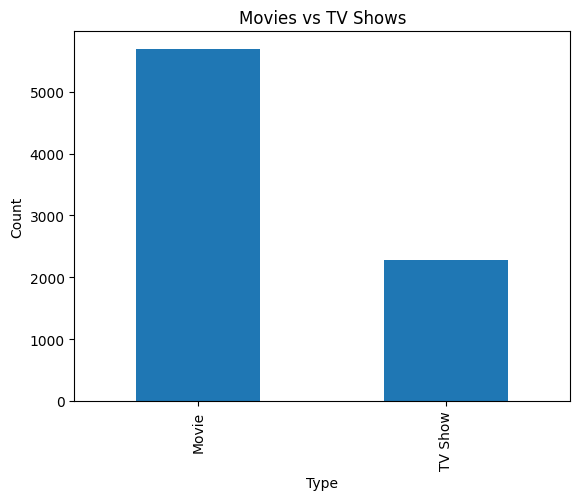

In [35]:
import matplotlib.pyplot as plt

type_count = df['type'].value_counts()

plt.figure()
type_count.plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

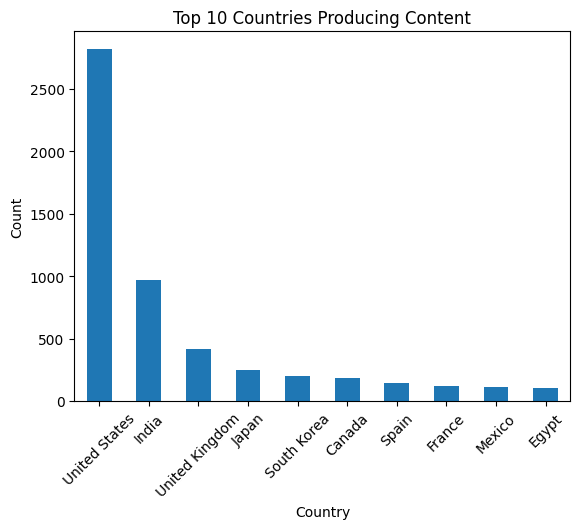

In [36]:
top_countries = df['country'].value_counts().head(10)

plt.figure()
top_countries.plot(kind='bar')
plt.title("Top 10 Countries Producing Content")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

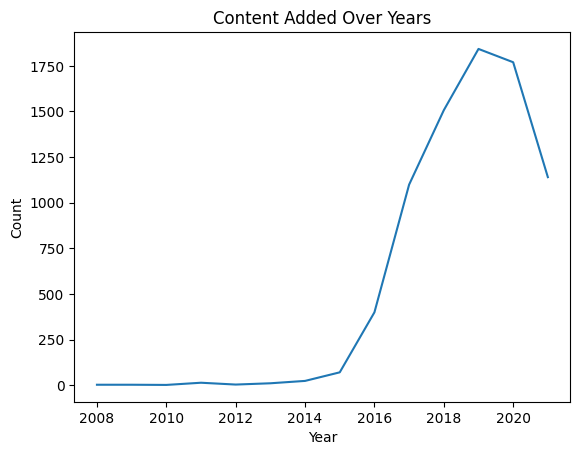

In [37]:
year_count = df['year_added'].value_counts().sort_index()

plt.figure()
year_count.plot(kind='line')
plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

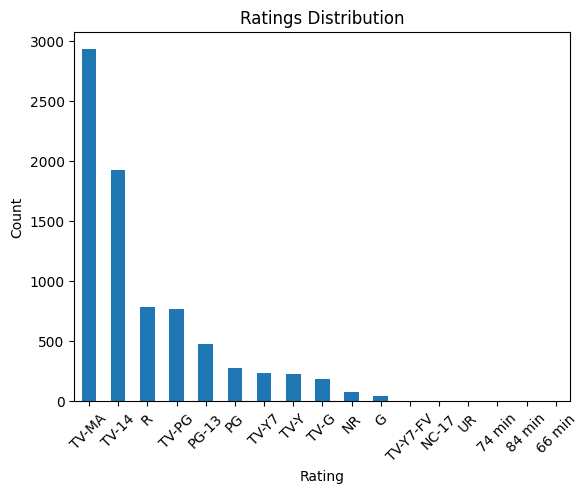

In [38]:
ratings = df['rating'].value_counts()

plt.figure()
ratings.plot(kind='bar')
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

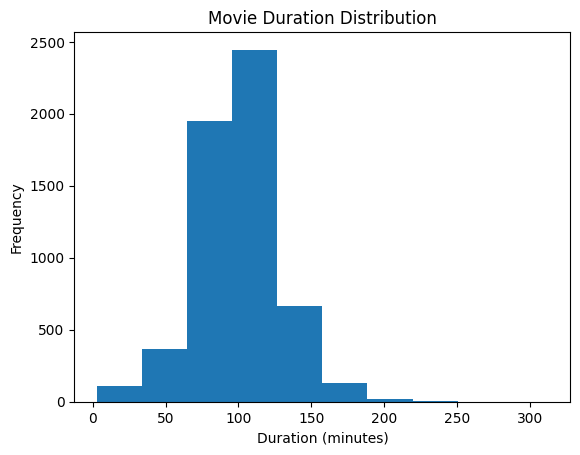

In [39]:
movies = df[df['type'] == 'Movie'].copy()

movies['duration'] = movies['duration'].str.replace(' min', '')
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

plt.figure()
plt.hist(movies['duration'].dropna())
plt.title("Movie Duration Distribution")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.show()

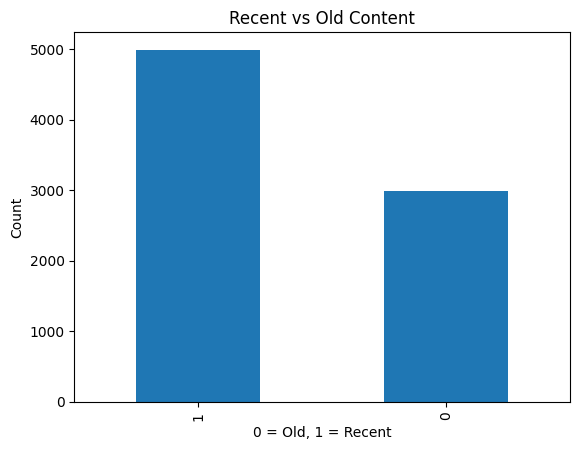

In [40]:
df['is_recent'] = np.where(df['release_year'] > 2015, 1, 0)

recent_count = df['is_recent'].value_counts()

plt.figure()
recent_count.plot(kind='bar')
plt.title("Recent vs Old Content")
plt.xlabel("0 = Old, 1 = Recent")
plt.ylabel("Count")
plt.show()

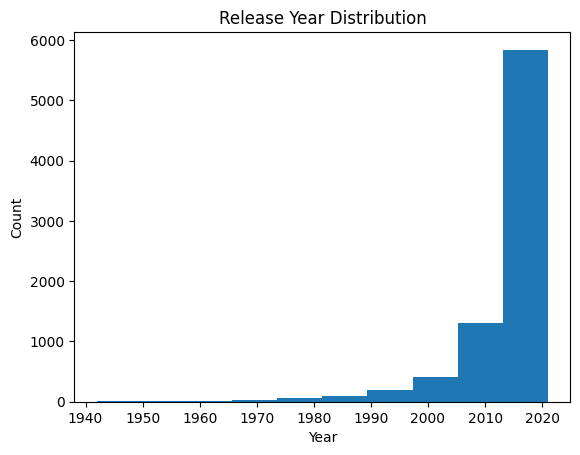

In [41]:
plt.figure()
plt.hist(df['release_year'].dropna())
plt.title("Release Year Distribution")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

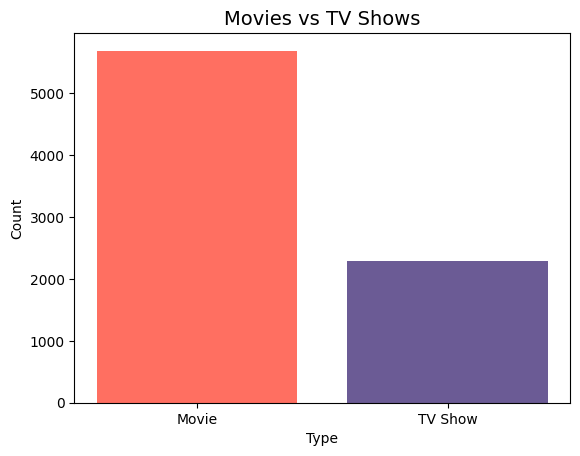

In [45]:
import matplotlib.pyplot as plt

type_count = df['type'].value_counts()

colors = ['#FF6F61', '#6B5B95']

plt.figure()
plt.bar(type_count.index, type_count.values, color=colors)
plt.title("Movies vs TV Shows", fontsize=14)
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

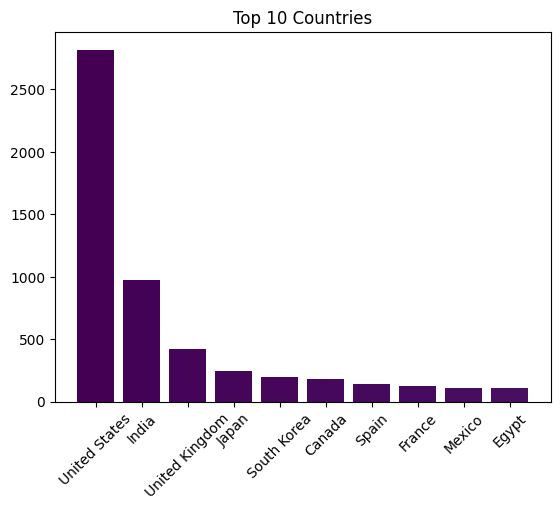

In [46]:
top_countries = df['country'].value_counts().head(10)

colors = plt.cm.viridis(range(len(top_countries)))

plt.figure()
plt.bar(top_countries.index, top_countries.values, color=colors)
plt.xticks(rotation=45)
plt.title("Top 10 Countries")
plt.show()

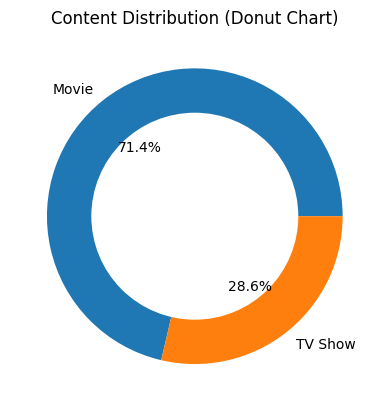

In [47]:
type_count = df['type'].value_counts()

plt.figure()
plt.pie(type_count, labels=type_count.index, autopct='%1.1f%%')
centre_circle = plt.Circle((0,0),0.70,fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Content Distribution (Donut Chart)")
plt.show()

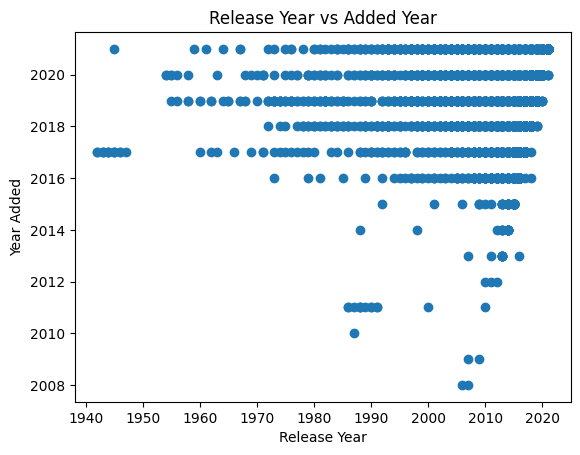

In [50]:
plt.figure()
plt.scatter(df['release_year'], df['year_added'])
plt.title("Release Year vs Added Year")
plt.xlabel("Release Year")
plt.ylabel("Year Added")
plt.show()

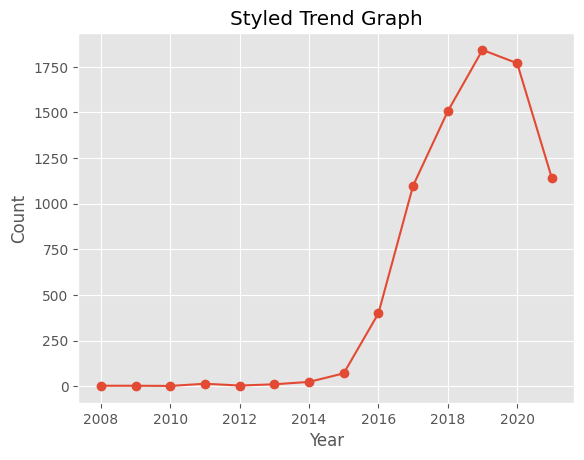

In [51]:
plt.style.use('ggplot')

plt.figure()
plt.plot(year_count.index, year_count.values, marker='o')
plt.title("Styled Trend Graph")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

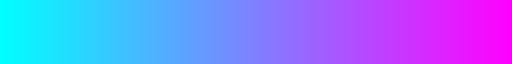

In [52]:
plt.cm.viridis
plt.cm.plasma
plt.cm.cool

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

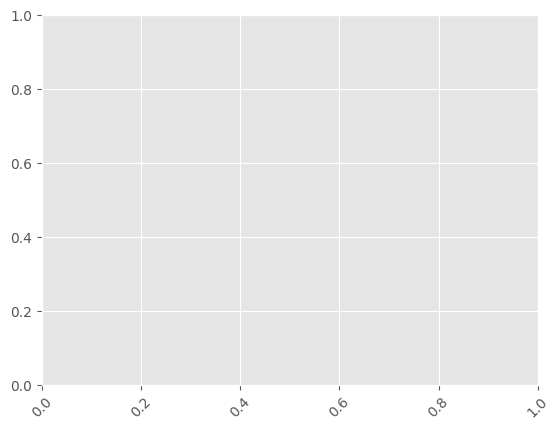

In [53]:
plt.xticks(rotation=45)